### Assignment 6: Path Planning for a Robot

**Objective:** Use A* Search to find an optimal path for a robot navigating a 2D grid.

**Problem Statement:** A robot must move from a start point to a goal in a grid while avoiding obstacles.

**Tasks:** Implement A* with:
- The Manhattan distance heuristic applies to grids without any diagonal movement.  
- The Euclidean distance heuristic is applicable to grids that allow diagonal movement.  
- Use a plotting library to visualize the found path.  
- Compare A* with BFS and Uniform Cost Search.  

Enter obstacle positions (row col):

Choose movement:
1. 4-direction (Manhattan)
2. 8-direction (Euclidean)

Results:
BFS expanded: 206
UCS expanded: 205
A* expanded: 60


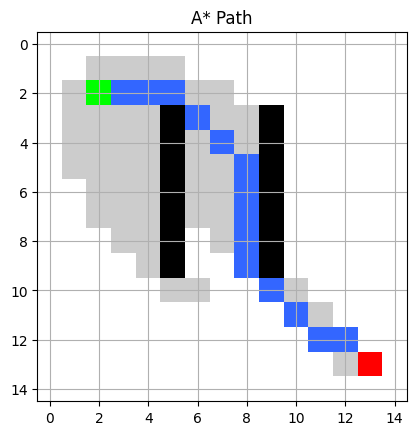

In [16]:
import heapq
import math
import time
from collections import deque
import numpy as np
import matplotlib.pyplot as plt

# ---------------- Heuristics ----------------
def manhattan(a, b):
    return abs(a[0]-b[0]) + abs(a[1]-b[1])

def euclidean(a, b):
    return math.hypot(a[0]-b[0], a[1]-b[1])

# ---------------- Neighbors ----------------
def get_neighbors(pos, grid, allow_diagonal=False):
    r, c = pos
    moves4 = [(-1,0),(1,0),(0,-1),(0,1)]
    moves8 = moves4 + [(-1,-1),(-1,1),(1,-1),(1,1)]
    moves = moves8 if allow_diagonal else moves4
    
    neighbors = []
    rows, cols = grid.shape
    
    for dr, dc in moves:
        nr, nc = r+dr, c+dc
        if 0 <= nr < rows and 0 <= nc < cols and grid[nr, nc] == 0:
            cost = math.sqrt(2) if allow_diagonal and dr!=0 and dc!=0 else 1
            neighbors.append(((nr,nc), cost))
    return neighbors

# ---------------- Path ----------------
def reconstruct(parent, start, goal):
    if goal not in parent:
        return None
    path = []
    cur = goal
    while cur != start:
        path.append(cur)
        cur = parent[cur]
    path.append(start)
    return path[::-1]

# ---------------- BFS ----------------
def bfs(grid, start, goal, allow_diagonal):
    q = deque([start])
    visited = set([start])
    parent = {start: None}
    expanded = 0
    
    while q:
        cur = q.popleft()
        expanded += 1
        if cur == goal:
            break
        for (nxt, _) in get_neighbors(cur, grid, allow_diagonal):
            if nxt not in visited:
                visited.add(nxt)
                parent[nxt] = cur
                q.append(nxt)
                
    return reconstruct(parent,start,goal), expanded, visited

# ---------------- UCS ----------------
def ucs(grid, start, goal, allow_diagonal):
    pq = [(0,start)]
    g = {start:0}
    parent = {start:None}
    visited = set()
    expanded = 0
    
    while pq:
        cost, cur = heapq.heappop(pq)
        if cur in visited:
            continue
        visited.add(cur)
        expanded += 1
        
        if cur == goal:
            break
        
        for (nxt, step) in get_neighbors(cur, grid, allow_diagonal):
            new = cost + step
            if nxt not in g or new < g[nxt]:
                g[nxt] = new
                parent[nxt] = cur
                heapq.heappush(pq, (new, nxt))
                
    return reconstruct(parent,start,goal), expanded, visited

# ---------------- A* ----------------
def astar(grid, start, goal, heuristic, allow_diagonal):
    pq = [(heuristic(start,goal),0,start)]
    g = {start:0}
    parent = {start:None}
    closed = set()
    expanded = 0
    
    while pq:
        f, cost, cur = heapq.heappop(pq)
        if cur in closed:
            continue
        closed.add(cur)
        expanded += 1
        
        if cur == goal:
            break
        
        for (nxt, step) in get_neighbors(cur, grid, allow_diagonal):
            new = cost + step
            if nxt not in g or new < g[nxt]:
                g[nxt] = new
                parent[nxt] = cur
                heapq.heappush(pq,(new+heuristic(nxt,goal),new,nxt))
                
    return reconstruct(parent,start,goal), expanded, closed

# ---------------- Plot ----------------
def plot(grid, start, goal, visited, path, title):
    img = np.ones((grid.shape[0],grid.shape[1],3))
    img[grid==1] = [0,0,0]
    
    for (r,c) in visited:
        if (r,c)!=start and (r,c)!=goal:
            img[r,c] = [0.8,0.8,0.8]
    
    if path:
        for (r,c) in path:
            if (r,c)!=start and (r,c)!=goal:
                img[r,c] = [0.2,0.4,1]
                
    sr,sc = start
    gr,gc = goal
    img[sr,sc] = [0,1,0]
    img[gr,gc] = [1,0,0]
    
    plt.imshow(img)
    plt.title(title)
    plt.grid(True)
    plt.show()

# ---------------- USER INPUT ----------------
rows = int(input("Enter number of rows: "))
cols = int(input("Enter number of columns: "))
grid = np.zeros((rows,cols), dtype=int)

sr = int(input("Enter start row: "))
sc = int(input("Enter start column: "))
gr = int(input("Enter goal row: "))
gc = int(input("Enter goal column: "))

start = (sr,sc)
goal = (gr,gc)

obs = int(input("Enter number of obstacles: "))
print("Enter obstacle positions (row col):")
for _ in range(obs):
    r,c = map(int,input().split())
    grid[r,c] = 1

print("\nChoose movement:")
print("1. 4-direction (Manhattan)")
print("2. 8-direction (Euclidean)")
choice = int(input("Enter choice: "))

if choice == 1:
    allow_diagonal = False
    heuristic = manhattan
else:
    allow_diagonal = True
    heuristic = euclidean

# ---------------- RUN ----------------
bfs_p, bfs_e, bfs_v = bfs(grid,start,goal,allow_diagonal)
ucs_p, ucs_e, ucs_v = ucs(grid,start,goal,allow_diagonal)
a_p, a_e, a_v = astar(grid,start,goal,heuristic,allow_diagonal)

print("\nResults:")
print("BFS expanded:", bfs_e)
print("UCS expanded:", ucs_e)
print("A* expanded:", a_e)

plot(grid,start,goal,a_v,a_p,"A* Path")
